# Test created Dataset (especially STL decomposition)

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from utils.data_loader import find_repo_root
from utils.plot_loader import create_subset2


# Load Data

In [2]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling")
GFOC_data = pd.read_parquet(DATA_DIR / "GFOC_modeling_20s.parquet")

print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

✅ Successfully loaded data with shape: (3157918, 22)
Column names in the dataset:
['orbital_decay', '|avg B|', 'F10.7 (LASP)', 'Bz GSE', 'Flow Speed (km/s', 'Temperature (K)', 'Kp (LASP)', 'median_decay_last_7D', 'median_decay_last_14D', 'median_decay_last_30D', 'orbital_period', 'phase', 'sin_harmonic_1', 'cos_harmonic_1', 'sin_harmonic_2', 'cos_harmonic_2', 'sin_harmonic_3', 'cos_harmonic_3', 'sin_harmonic_4', 'cos_harmonic_4', 'oscillation', 'trend']
Sample rate: 20s


# Plot

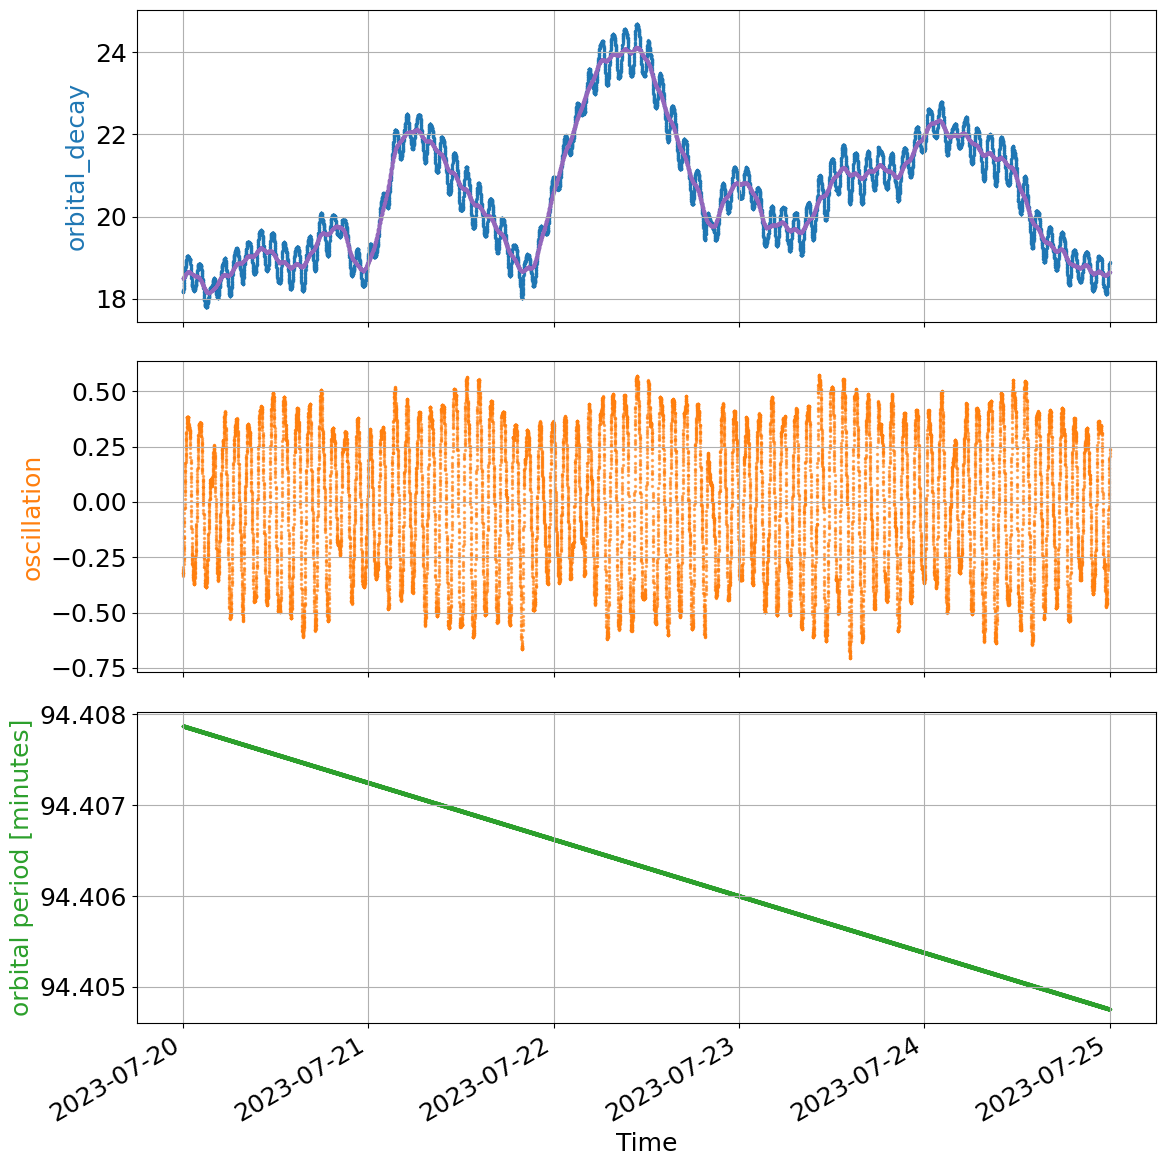

In [7]:
# =========================== Input ===================================
start_date = '2023-07-20 00:00:00'
end_date = '2023-07-25 00:00:00'
# =====================================================================

subset = create_subset2(GFOC_data, start_date, end_date, resample_rate='20s')
# plot all features from columns_needed
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axes[0].scatter(subset.index, subset['orbital_decay'], s=2, c='C0', alpha=0.6)
axes[0].scatter(subset.index, subset['trend'], s=2, c='C4', alpha=0.6)
axes[0].set_ylabel('orbital_decay', color='C0')
axes[0].grid(True)

axes[1].scatter(subset.index, subset['oscillation'], s=2, c='C1', alpha=0.6)
axes[1].set_ylabel('oscillation', color='C1')
axes[1].grid(True)

axes[2].scatter(subset.index, subset['orbital_period']/60, s=2, c='C2', alpha=0.6)
axes[2].set_ylabel('orbital period [minutes]', color='C2')
axes[2].set_xlabel('Time')
axes[2].ticklabel_format(axis='y', style='plain', useOffset=False)
axes[2].grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Kp index

Geomagentic storms are ranked from G1 to G5 based on their Kp index with
- Inactive: Kp <4
- G0: 4 <= Kp <5 (Active)
- G1: 5 <= Kp <6 (Minor)
- G2: 6 <= Kp <7 (Moderate)
- G3: 7 <= Kp <8 (Strong)
- G4: 8 <= Kp <9 (Severe)
- G5: 9 <= Kp (Extreme)

In [4]:
# =========================== Input ===================================
start_date = '2023-01-01 00:00:00'
end_date = '2025-01-01 00:00:00'
# =====================================================================

bins = [-np.inf, 4, 5, 6, 7, 8, 9, np.inf]
labels = [
    'Inactive',
    'G0 (Active)',
    'G1 (Minor)',
    'G2 (Moderate)',
    'G3 (Strong)',
    'G4 (Severe)',
    'G5 (Extreme)'
]

subset['Kp_category'] = pd.cut(
    subset['Kp (LASP)'],
    bins=bins,
    labels=labels,
    right=False
)

# statistics
kp_stats = subset['Kp_category'].value_counts().sort_index()
print(kp_stats)
kp_percent = kp_stats / kp_stats.sum() * 100
stats_df = pd.DataFrame({
    'Count': kp_stats,
    'Percent (%)': kp_percent.round(2)
})
print(stats_df)


Kp_category
Inactive         20522
G0 (Active)       1077
G1 (Minor)           0
G2 (Moderate)        0
G3 (Strong)          0
G4 (Severe)          0
G5 (Extreme)         0
Name: count, dtype: int64
               Count  Percent (%)
Kp_category                      
Inactive       20522        95.01
G0 (Active)     1077         4.99
G1 (Minor)         0         0.00
G2 (Moderate)      0         0.00
G3 (Strong)        0         0.00
G4 (Severe)        0         0.00
G5 (Extreme)       0         0.00


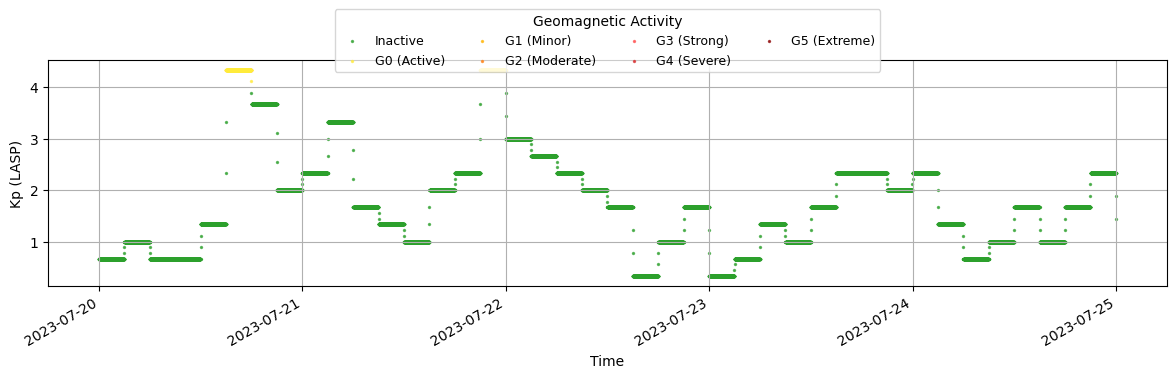

In [5]:
category_colors = {
    'Inactive': '#2ca02c',       # green
    'G0 (Active)': '#ffeb3b',     # yellow
    'G1 (Minor)': '#ffb300',
    'G2 (Moderate)': '#ff7f0e',
    'G3 (Strong)': '#ff4c4c',
    'G4 (Severe)': '#d62728',
    'G5 (Extreme)': '#8b0000'     # dark red
}

fig, ax = plt.subplots(figsize=(12, 4))

for category, color in category_colors.items():
    mask = subset['Kp_category'] == category
    ax.scatter(
        subset.index[mask],
        subset.loc[mask, 'Kp (LASP)'],
        s=2,
        color=color,
        label=category,
        alpha=0.7
    )

ax.set_ylabel('Kp (LASP)')
ax.set_xlabel('Time')
ax.grid(True)
ax.legend(
    title='Geomagnetic Activity',
    ncol=4,
    fontsize=9,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.25)
)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


# Median Decay

Median decay rate: 27.9308 m/day
Std decay rate: 13.9295 m/day
Mean decay rate: 31.6273 m/day


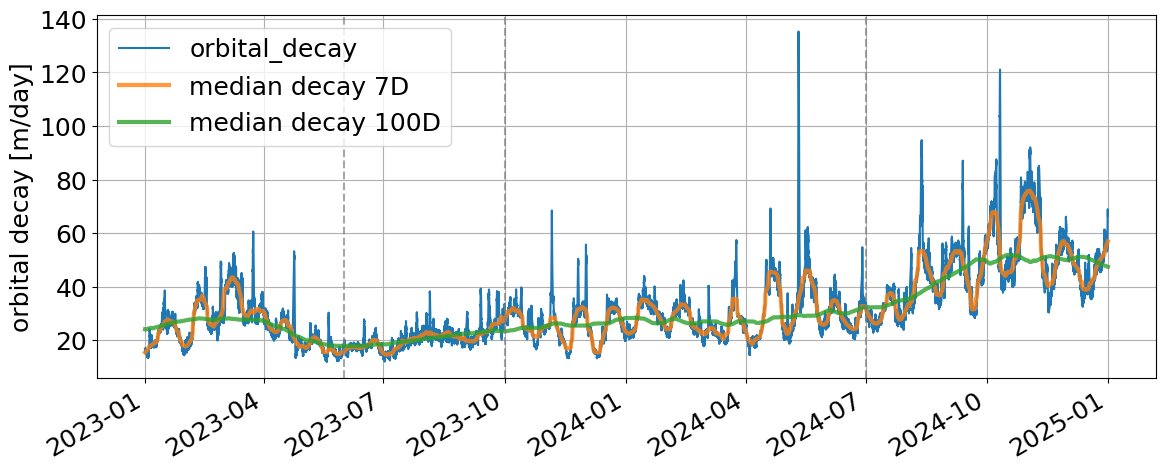

In [6]:
# =========================== Input ===================================
start_date = '2023-01-01 00:00:00'
end_date = '2025-01-01 00:00:00'
centered = True
# =====================================================================

subset = create_subset2(GFOC_data, start_date, end_date, resample_rate='5min')

# print median and mean decay rate for subset
print(f"Median decay rate: {subset['orbital_decay'].median():.4f} m/day")
print(f'Std decay rate: {subset["orbital_decay"].std():.4f} m/day')
print(f"Mean decay rate: {subset['orbital_decay'].mean():.4f} m/day")

plt.rcParams.update({'font.size': 18})
fig, ax = plt.subplots(1, 1, figsize=(12, 5), sharex=True)

ax.plot(subset.index, subset['orbital_decay'], alpha=1.0, label='orbital_decay')
if centered:
    dt_seconds = (subset.index[1] - subset.index[0]).total_seconds()

    # daily means
    subset['median_decay_last_7D'] = subset['orbital_decay'].rolling(window=int(7*24*60*(60/dt_seconds)), min_periods=1, center=True).median()
    subset['median_decay_last_14D'] = subset['orbital_decay'].rolling(window=int(14*24*60*(60/dt_seconds)), min_periods=1, center=True).median()
    subset['median_decay_last_30D'] = subset['orbital_decay'].rolling(window=int(30*24*60*(60/dt_seconds)), min_periods=1, center=True).median()
    subset['median_decay_last_100D'] = subset['orbital_decay'].rolling(window=int(100*24*60*(60/dt_seconds)), min_periods=1, center=True).median()
ax.plot(subset.index, subset['median_decay_last_7D'], alpha=0.8, lw = 3, label='median decay 7D')
# ax.scatter(subset.index, subset['median_decay_last_14D'], s=2, alpha=0.6, label='median_decay_last_14D')
# ax.plot(subset.index, subset['median_decay_last_30D'], alpha=0.8, lw = 3, label='median decay last 30D')
ax.plot(subset.index, subset['median_decay_last_100D'], alpha=0.8, lw = 3, label='median decay 100D')

# vertical lines at specific dates
vertical_dates = ['2023-06-01', '2023-10-01', '2024-07-01']
for v_date in vertical_dates:
    ax.axvline(pd.to_datetime(v_date), color='gray', linestyle='--', alpha=0.7)
ax.set_ylabel('orbital decay [m/day]')
ax.grid(True)
ax.legend(loc='upper left')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()